🔹 Step 1: Load the dataset


In [1]:
import json
import pandas as pd

# Load the synthetic SMS dataset
with open("data/anomaly_detection/synthetic_sms_dataset.json", "r") as f:
    sms_data = json.load(f)

# View first 3 SMS messages
for i in range(3):
    print(sms_data[i]["text"])


0.57 debited from AC XXXXXXXX2154 as POS TXN on 16 Apr 2025 03:29 at UnknownVendor. Avl Bal 2968.36 Call 94112448888 for info
393.61 debited from AC XXXXXXXX2154 as POS TXN on 02 Apr 2025 15:12 at Keells. Avl Bal 2531.36 Call 94112448888 for info
99.39 debited from AC XXXXXXXX2154 as POS TXN on 01 Apr 2025 21:17 at Cafe Mocha. Avl Bal 1928.61 Call 94112448888 for info


🔹 Step 2: Parse SMS into structured features


In [2]:
import re
from datetime import datetime

# Parse the SMS text into structured data
parsed_data = []

for sms in sms_data:
    text = sms["text"]
    
    # Extract amount
    amount_match = re.search(r"([\d,.]+)\s+debited", text)
    amount = float(amount_match.group(1).replace(",", "")) if amount_match else None

    # Extract datetime
    datetime_match = re.search(r"on (\d{2} \w{3} \d{4} \d{2}:\d{2})", text)
    dt = datetime.strptime(datetime_match.group(1), "%d %b %Y %H:%M") if datetime_match else None

    # Extract merchant
    merchant_match = re.search(r"at ([^.]+)\.", text)
    merchant = merchant_match.group(1).strip() if merchant_match else "Unknown"

    # Append structured row
    parsed_data.append({
        "amount": amount,
        "datetime": dt,
        "hour": dt.hour if dt else None,
        "day_of_week": dt.strftime("%A") if dt else None,
        "merchant": merchant
    })

df = pd.DataFrame(parsed_data)
df.head()


,amount,datetime,hour,day_of_week,merchant
0,0.57,2025-04-16 03:29:00,3,Wednesday,UnknownVendor
1,393.61,2025-04-02 15:12:00,15,Wednesday,Keells
2,99.39,2025-04-01 21:17:00,21,Tuesday,Cafe Mocha
3,146.05,2025-04-07 22:00:00,22,Monday,Cafe Mocha
4,86.33,2025-04-13 02:51:00,2,Sunday,Domino's


🔹 Step 3: Encode categorical values + prepare features


In [3]:
from sklearn.preprocessing import LabelEncoder

# Encode 'merchant' into numeric
merchant_encoder = LabelEncoder()
df["merchant_encoded"] = merchant_encoder.fit_transform(df["merchant"])

# Map day of week to number (Monday=0, ..., Sunday=6)
df["day_num"] = df["day_of_week"].map({
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
})

# Final feature set
features = df[["amount", "hour", "day_num", "merchant_encoded"]]
features.head()


,amount,hour,day_num,merchant_encoded
0,0.57,3,2,8
1,393.61,15,2,4
2,99.39,21,1,1
3,146.05,22,0,1
4,86.33,2,6,3


🔹 Step 4: Train Isolation Forest


In [4]:
from sklearn.ensemble import IsolationForest

# Train model
model = IsolationForest(contamination=0.07, random_state=42)
df["is_anomaly"] = model.fit_predict(features)

# Convert -1 (outlier) to True, 1 (inlier) to False
df["is_anomaly"] = df["is_anomaly"] == -1
df["is_anomaly"].value_counts()


is_anomaly
False    186
True      14
Name: count, dtype: int64

🔹 Step 5: Save flagged results to JSON

In [5]:
# Add anomaly flag back to SMS messages
for i, row in df.iterrows():
    sms_data[i]["is_anomaly"] = bool(row["is_anomaly"])

# Save to new JSON file
with open("data/anomaly_detection/flagged_sms_transactions.json", "w") as f:
    json.dump(sms_data, f, indent=2)

print("✅ Anomaly detection results saved to flagged_sms_transactions.json")


✅ Anomaly detection results saved to flagged_sms_transactions.json


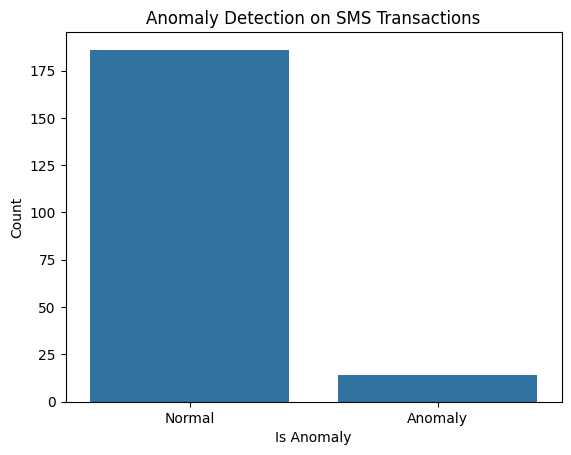

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["is_anomaly"])
plt.title("Anomaly Detection on SMS Transactions")
plt.xlabel("Is Anomaly")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.show()
